# Домашнее задание №4. Обучение без учителя

In [1]:
%pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Произведем импорт всего необходимого:

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    pairwise_distances
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import umap.umap_ as umap

2026-04-24 13:17:21.001068: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 13:17:21.051494: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-24 13:17:22.202772: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Зададим базовые настройки визуализации и отображения таблиц, которые будут использоваться далее в работе.

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

Определим функции для подготовки данных к кластеризации.

Так как в этой работе решается задача обучения без учителя, предобработка не должна использовать целевую переменную. Поэтому отдельно выделяется псевдо-таргет, а для признаков применяются только базовые преобразования: заполнение пропусков, масштабирование числовых признаков и one-hot encoding категориальных признаков.

Категориальные признаки с большим числом уникальных значений исключаются, чтобы не слишком увеличивать размерность признакового пространства.

Для алгоритмов кластеризации важно, чтобы признаки находились в сопоставимых масштабах, так как большинство методов используют расстояния (например, евклидово).
Категориальные признаки кодируются, чтобы их можно было использовать в численных алгоритмах.
Псевдо-таргет исключается из признакового пространства, так как он используется только для внешней оценки качества кластеризации.

In [4]:
def build_unsupervised_preprocessor(X_df, max_cat_unique=30):
    X_df = X_df.copy()

    numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

    # Оставим только не слишком "широкие" категориальные признаки
    low_cardinality_cat_cols = []
    dropped_high_cardinality_cols = []

    for col in categorical_cols:
        nunique = X_df[col].nunique(dropna=True)
        if nunique <= max_cat_unique:
            low_cardinality_cat_cols.append(col)
        else:
            dropped_high_cardinality_cols.append(col)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, low_cardinality_cat_cols),
        ],
        remainder="drop"
    )

    return preprocessor, numeric_cols, low_cardinality_cat_cols, dropped_high_cardinality_cols


def prepare_unsupervised_dataset(
    df,
    pseudo_target_col,
    columns_to_drop=None,
    sample_size=None,
    random_state=42,
    max_cat_unique=30,
    fit_preprocessor=True,
    preprocessor=None
):
    data = df.copy()

    if columns_to_drop is None:
        columns_to_drop = []

    # Удаляем строки без псевдо-таргета
    data = data.dropna(subset=[pseudo_target_col]).reset_index(drop=True)

    # Подвыборка
    if sample_size is not None and len(data) > sample_size:
        data = data.sample(sample_size, random_state=random_state).reset_index(drop=True)

    # Псевдо-таргет отдельно
    y_pseudo_raw = data[pseudo_target_col].astype(str).copy()

    # Удаляем target и лишние столбцы из X
    drop_cols = [pseudo_target_col] + [c for c in columns_to_drop if c in data.columns]
    X_df = data.drop(columns=drop_cols, errors="ignore").copy()

    # Иногда полезно убрать полностью пустые столбцы
    all_nan_cols = X_df.columns[X_df.isna().all()].tolist()
    if all_nan_cols:
        X_df = X_df.drop(columns=all_nan_cols)

    # Строим / применяем препроцессор
    if fit_preprocessor:
        preprocessor, num_cols, cat_cols, dropped_cat_cols = build_unsupervised_preprocessor(
            X_df, max_cat_unique=max_cat_unique
        )
        X = preprocessor.fit_transform(X_df)
    else:
        if preprocessor is None:
            raise ValueError("Если fit_preprocessor=False, нужно передать preprocessor")
        X = preprocessor.transform(X_df)

        # Для согласованности просто собираем инфо по текущему X_df
        _, num_cols, cat_cols, dropped_cat_cols = build_unsupervised_preprocessor(
            X_df, max_cat_unique=max_cat_unique
        )

    # Кодируем псевдо-таргет только для оценки / визуализаций
    label_encoder = LabelEncoder()
    y_pseudo_encoded = label_encoder.fit_transform(y_pseudo_raw)

    info = {
        "original_shape": data.shape,
        "feature_df_shape": X_df.shape,
        "transformed_shape": X.shape,
        "numeric_cols": num_cols,
        "categorical_cols_used": cat_cols,
        "categorical_cols_dropped_high_cardinality": dropped_cat_cols,
        "all_nan_cols_dropped": all_nan_cols,
    }

    print("Подготовка завершена")
    print(f"Исходная форма data: {info['original_shape']}")
    print(f"Форма X до трансформации: {info['feature_df_shape']}")
    print(f"Форма X после трансформации: {info['transformed_shape']}")
    print(f"Числовых признаков: {len(num_cols)}")
    print(f"Категориальных one-hot признаков: {len(cat_cols)}")
    print(f"Отброшено high-cardinality категориальных: {len(dropped_cat_cols)}")
    print(f"Удалено полностью пустых столбцов: {len(all_nan_cols)}")

    return X, y_pseudo_raw, y_pseudo_encoded, label_encoder, preprocessor, info

# Загрузка датасетов 
IEEE-CIS Fraud Detection.
В качестве псевдо-таргета используется ProductCD. Он исключается из матрицы признаков и далее применяется только для расчёта внешних метрик и визуализаций. Для ускорения экспериментов используется случайная подвыборка из 8 000 объектов.

In [5]:
ieee_df = pd.read_csv("/home/jupyter/datasets/ieee-fraud-detection/train_public.csv")

X_ieee, y_ieee_raw, y_ieee, le_ieee, ieee_preprocessor, ieee_info = prepare_unsupervised_dataset(
    df=ieee_df,
    pseudo_target_col="ProductCD",
    columns_to_drop=[],
    sample_size=8000,
    random_state=42,
    max_cat_unique=15
)

Подготовка завершена
Исходная форма data: (8000, 434)
Форма X до трансформации: (8000, 433)
Форма X после трансформации: (8000, 457)
Числовых признаков: 403
Категориальных one-hot признаков: 24
Отброшено high-cardinality категориальных: 6
Удалено полностью пустых столбцов: 0


Аналогично подготовим датасет NYC Taxi.

В качестве псевдо-таргета используется признак payment_type. Он не участвует в обучении кластеризации и используется только для внешней оценки. Для ускорения расчётов также берётся подвыборка из 8 000 объектов.

In [6]:
nyc_df = pd.read_csv("/home/jupyter/datasets/nyc-taxi-small-public/X_train_public.csv")

X_nyc, y_nyc_raw, y_nyc, le_nyc, nyc_preprocessor, nyc_info = prepare_unsupervised_dataset(
    df=nyc_df,
    pseudo_target_col="payment_type",
    columns_to_drop=[],
    sample_size=8000,
    random_state=42,
    max_cat_unique=20
)

Подготовка завершена
Исходная форма data: (8000, 18)
Форма X до трансформации: (8000, 17)
Форма X после трансформации: (8000, 17)
Числовых признаков: 15
Категориальных one-hot признаков: 1
Отброшено high-cardinality категориальных: 1
Удалено полностью пустых столбцов: 0


Реализуем собственную версию алгоритма k-means.

Алгоритм случайно инициализирует центроиды, затем итеративно относит объекты к ближайшему центру и пересчитывает центроиды как среднее объектов в каждом кластере. Для повышения устойчивости используется несколько запусков с разной инициализацией, после чего выбирается вариант с минимальным значением inertia.

In [7]:
class MyKMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42, n_init=10):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.n_init = n_init
        
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def _init_centroids(self, X, rng):
        idx = rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[idx].copy()

    def _assign_clusters(self, X, centroids):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels, old_centroids):
        new_centroids = np.zeros_like(old_centroids)
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) == 0:
                new_centroids[k] = old_centroids[k]
            else:
                new_centroids[k] = cluster_points.mean(axis=0)
        return new_centroids

    def _compute_inertia(self, X, labels, centroids):
        return np.sum((X - centroids[labels]) ** 2)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        best_inertia = np.inf
        best_centroids = None
        best_labels = None
        
        base_rng = np.random.RandomState(self.random_state)

        for _ in range(self.n_init):
            rng = np.random.RandomState(base_rng.randint(0, 10**9))
            centroids = self._init_centroids(X, rng)

            for _ in range(self.max_iter):
                labels = self._assign_clusters(X, centroids)
                new_centroids = self._update_centroids(X, labels, centroids)

                shift = np.linalg.norm(new_centroids - centroids)
                centroids = new_centroids

                if shift < self.tol:
                    break

            labels = self._assign_clusters(X, centroids)
            inertia = self._compute_inertia(X, labels, centroids)

            if inertia < best_inertia:
                best_inertia = inertia
                best_centroids = centroids.copy()
                best_labels = labels.copy()

        self.cluster_centers_ = best_centroids
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._assign_clusters(X, self.cluster_centers_)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

Реализуем собственную версию метода главных компонент (PCA).

Метод позволяет понизить размерность данных за счёт перехода в новое пространство признаков, соответствующее направлениям максимальной дисперсии. Для этого вычисляются собственные значения и собственные векторы ковариационной матрицы, после чего данные проецируются на первые n_components компонент.

In [8]:
class MyPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        cov = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]
        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total_var

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        X_centered = X - self.mean_
        return X_centered @ self.components_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Определим функции для расчёта метрик качества кластеризации.

Для внутренней оценки используются среднее внутрикластерное расстояние, среднее межкластерное расстояние и silhouette. Для внешней оценки используются homogeneity, completeness и V-measure, которые сравнивают полученные кластеры с псевдо-таргетом.

Для DBSCAN отдельно учитывается доля объектов, отнесённых к шуму.

In [9]:
def mean_intra_cluster_distance(X, labels, metric='euclidean', max_points_per_cluster=400):
    unique_labels = [l for l in np.unique(labels) if l != -1]
    values = []

    for label in unique_labels:
        cluster = X[labels == label]
        if len(cluster) < 2:
            continue

        if len(cluster) > max_points_per_cluster:
            idx = np.random.choice(len(cluster), max_points_per_cluster, replace=False)
            cluster = cluster[idx]

        d = pairwise_distances(cluster, metric=metric)
        upper = d[np.triu_indices_from(d, k=1)]
        if len(upper) > 0:
            values.append(upper.mean())

    return np.mean(values) if values else np.nan


def mean_inter_cluster_distance(X, labels, metric='euclidean', max_points_per_cluster=250):
    unique_labels = [l for l in np.unique(labels) if l != -1]
    values = []

    for a, b in combinations(unique_labels, 2):
        Xa = X[labels == a]
        Xb = X[labels == b]

        if len(Xa) > max_points_per_cluster:
            idx = np.random.choice(len(Xa), max_points_per_cluster, replace=False)
            Xa = Xa[idx]
        if len(Xb) > max_points_per_cluster:
            idx = np.random.choice(len(Xb), max_points_per_cluster, replace=False)
            Xb = Xb[idx]

        d = pairwise_distances(Xa, Xb, metric=metric)
        values.append(d.mean())

    return np.mean(values) if values else np.nan


def clustering_metrics(X, labels, y_true=None, metric='euclidean'):
    result = {}

    unique_labels = np.unique(labels)
    n_clusters = len([x for x in unique_labels if x != -1])
    noise_ratio = np.mean(labels == -1) if np.any(labels == -1) else 0.0

    result["n_clusters"] = n_clusters
    result["noise_ratio"] = noise_ratio
    result["intra_mean"] = mean_intra_cluster_distance(X, labels, metric=metric)
    result["inter_mean"] = mean_inter_cluster_distance(X, labels, metric=metric)

    valid_mask = labels != -1

    if valid_mask.sum() > 1 and len(np.unique(labels[valid_mask])) > 1:
        result["silhouette"] = silhouette_score(X[valid_mask], labels[valid_mask], metric=metric)
    else:
        result["silhouette"] = np.nan

    if y_true is not None and valid_mask.sum() > 0:
        result["homogeneity"] = homogeneity_score(y_true[valid_mask], labels[valid_mask])
        result["completeness"] = completeness_score(y_true[valid_mask], labels[valid_mask])
        result["v_measure"] = v_measure_score(y_true[valid_mask], labels[valid_mask])
    else:
        result["homogeneity"] = np.nan
        result["completeness"] = np.nan
        result["v_measure"] = np.nan

    return result

Определим функции для запуска серий экспериментов.

Для каждого алгоритма перебираются разные значения гиперпараметров, после чего для каждой конфигурации считаются метрики качества. Результаты сохраняются в едином формате, чтобы затем объединить их в общую таблицу экспериментов.

In [58]:
def run_kmeans_experiments(X, y_true, dataset_name, k_list, random_state=42):
    rows = []
    for k in k_list:
        model = MyKMeans(
            n_clusters=k,
            max_iter=100,
            tol=1e-4,
            random_state=random_state,
            n_init=10
        )
        labels = model.fit_predict(X)
        metrics = clustering_metrics(X, labels, y_true, metric='euclidean')

        row = {
            "dataset": dataset_name,
            "algo": "kmeans",
            "metric": "euclidean",
            "k": k,
            "linkage": None,
            "eps": None,
            "min_samples": None,
            "random_state": random_state,
            "sample_size": X.shape[0],
            **metrics
        }
        rows.append(row)
    return pd.DataFrame(rows)


def run_agglomerative_experiments(X, y_true, dataset_name, n_clusters_list, linkages):
    rows = []
    for linkage in linkages:
        for k in n_clusters_list:
            if linkage == "ward":
                model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage,
                    metric="euclidean"
                )
            else:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage,
                    metric="euclidean"
                )

            labels = model.fit_predict(X)
            metrics = clustering_metrics(X, labels, y_true, metric='euclidean')

            row = {
                "dataset": dataset_name,
                "algo": "agglomerative",
                "metric": "euclidean",
                "k": k,
                "linkage": linkage,
                "eps": None,
                "min_samples": None,
                "random_state": None,
                "sample_size": X.shape[0],
                **metrics
            }
            rows.append(row)
    return pd.DataFrame(rows)


def run_dbscan_experiments(X, y_true, dataset_name, eps_list, min_samples_list):
    rows = []
    for eps in eps_list:
        for min_samples in min_samples_list:
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                metric="euclidean"
            )
            labels = model.fit_predict(X)
            metrics = clustering_metrics(X, labels, y_true, metric='euclidean')

            row = {
                "dataset": dataset_name,
                "algo": "dbscan",
                "metric": "euclidean",
                "k": None,
                "linkage": None,
                "eps": eps,
                "min_samples": min_samples,
                "random_state": None,
                "sample_size": X.shape[0],
                **metrics
            }
            rows.append(row)
    return pd.DataFrame(rows)

def run_agglomerative_threshold_experiments(X, y_true, dataset_name, thresholds, linkages, sample_size=2000, random_state=42, max_clusters_for_metrics=50):
    if len(X) > sample_size:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(len(X), sample_size, replace=False)
        X_work = X[idx]
        y_work = y_true[idx]
    else:
        X_work = X
        y_work = y_true

    rows = []

    for linkage in linkages:
        for h in thresholds:
            model = AgglomerativeClustering(
                n_clusters=None,
                distance_threshold=h,
                linkage=linkage,
                metric="euclidean"
            )

            labels = model.fit_predict(X_work)
            n_clusters = len(np.unique(labels))

            if n_clusters < 2 or n_clusters > max_clusters_for_metrics:
                metrics = {
                    "n_clusters": n_clusters,
                    "noise_ratio": 0.0,
                    "intra_mean": np.nan,
                    "inter_mean": np.nan,
                    "silhouette": np.nan,
                    "homogeneity": np.nan,
                    "completeness": np.nan,
                    "v_measure": np.nan
                }
            else:
                metrics = clustering_metrics(X_work, labels, y_work, metric="euclidean")

            row = {
                "dataset": dataset_name,
                "algo": "agglomerative_h",
                "metric": "euclidean",
                "k": None,
                "linkage": linkage,
                "distance_threshold": h,
                "eps": None,
                "min_samples": None,
                "random_state": random_state,
                "sample_size": len(X_work),
                **metrics
            }

            rows.append(row)

    return pd.DataFrame(rows)

Зададим наборы гиперпараметров для проведения экспериментов.

Будем варьировать:
- число кластеров k для k-means и агломеративной кластеризации,
- тип linkage для агломеративной кластеризации,
- параметры eps и min_samples для DBSCAN.

In [59]:
k_list = [2, 3, 4, 5, 6]
linkages = ["ward", "complete", "average", "single"]
eps_list = [0.5, 1.0, 1.5]
min_samples_list = [5, 10, 20]
thresholds = [10, 20, 40]

Проведём эксперименты для датасета IEEE-CIS.

Для каждого алгоритма перебираются заданные гиперпараметры, после чего результаты объединяются в единую таблицу для дальнейшего анализа.

In [63]:
ieee_kmeans_df = run_kmeans_experiments(X_ieee, y_ieee, "IEEE-CIS", k_list, random_state=42)

In [64]:
ieee_agg_df = run_agglomerative_experiments(X_ieee, y_ieee, "IEEE-CIS", k_list, linkages)

In [60]:
ieee_dbscan_df = run_dbscan_experiments(X_ieee, y_ieee, "IEEE-CIS", eps_list, min_samples_list)

In [65]:
ieee_agg_h_df = run_agglomerative_threshold_experiments(X_ieee, y_ieee, "IEEE-CIS", thresholds=[10, 20, 40], linkages=["ward", "average", "complete"],sample_size=8000, random_state=42)

In [67]:
ieee_results = pd.concat([ieee_kmeans_df, ieee_agg_df, ieee_agg_h_df, ieee_dbscan_df], ignore_index=True)
ieee_results.head()

,dataset,algo,metric,k,linkage,eps,min_samples,random_state,sample_size,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure,distance_threshold
0,IEEE-CIS,kmeans,euclidean,2,None,NaN,None,42,8000,2,0.0,28.325057,31.083019,0.448123,0.329969,0.846970,0.474916,NaN
1,IEEE-CIS,kmeans,euclidean,3,None,NaN,None,42,8000,3,0.0,96.519378,148.177979,0.417220,0.337231,0.844103,0.481926,NaN
2,IEEE-CIS,kmeans,euclidean,4,None,NaN,None,42,8000,4,0.0,74.433177,115.411741,0.428696,0.396589,0.789279,0.527916,NaN
3,IEEE-CIS,kmeans,euclidean,5,None,NaN,None,42,8000,5,0.0,92.957131,160.644601,0.037891,0.428836,0.410729,0.419587,NaN
4,IEEE-CIS,kmeans,euclidean,6,None,NaN,None,42,8000,6,0.0,77.415243,144.884049,0.050698,0.502002,0.420118,0.457424,NaN


In [68]:
def pretty_display_ieee(df):
    display(
        df
        .sort_values("v_measure", ascending=False)
        .style
        .format(precision=3)
        .background_gradient(subset=["v_measure"], cmap="Greens")
        .background_gradient(subset=["silhouette"], cmap="Blues")
        .background_gradient(subset=["noise_ratio"], cmap="Reds_r")
        .set_caption("IEEE-CIS: результаты кластеризации")
    )

pretty_display_ieee(ieee_results)

,dataset,algo,metric,k,linkage,eps,min_samples,random_state,sample_size,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure,distance_threshold
41,IEEE-CIS,dbscan,euclidean,None,None,1.500,10,None,8000,1,0.999,1.345,nan,nan,1.000,1.000,1.000,nan
37,IEEE-CIS,dbscan,euclidean,None,None,1.000,5,None,8000,2,0.998,0.818,14.687,0.940,1.000,1.000,1.000,nan
2,IEEE-CIS,kmeans,euclidean,4,None,nan,None,42,8000,4,0.000,74.433,115.412,0.429,0.397,0.789,0.528,nan
9,IEEE-CIS,agglomerative,euclidean,6,ward,nan,None,None,8000,6,0.000,85.973,207.021,0.429,0.392,0.792,0.525,nan
1,IEEE-CIS,kmeans,euclidean,3,None,nan,None,42,8000,3,0.000,96.519,148.178,0.417,0.337,0.844,0.482,nan
7,IEEE-CIS,agglomerative,euclidean,4,ward,nan,None,None,8000,4,0.000,107.141,192.092,0.420,0.336,0.847,0.481,nan
8,IEEE-CIS,agglomerative,euclidean,5,ward,nan,None,None,8000,5,0.000,99.333,234.626,0.420,0.336,0.846,0.481,nan
6,IEEE-CIS,agglomerative,euclidean,3,ward,nan,None,None,8000,3,0.000,115.228,192.781,0.432,0.330,0.848,0.475,nan
0,IEEE-CIS,kmeans,euclidean,2,None,nan,None,42,8000,2,0.000,28.325,31.083,0.448,0.330,0.847,0.475,nan
5,IEEE-CIS,agglomerative,euclidean,2,ward,nan,None,None,8000,2,0.000,26.897,35.082,0.447,0.327,0.851,0.472,nan


Аналогично проведём эксперименты для датасета NYC Taxi.

Полученные результаты также объединяются в таблицу, что позволяет сравнить алгоритмы и выбрать наиболее подходящие параметры.

In [22]:
nyc_kmeans_df = run_kmeans_experiments(X_nyc, y_nyc, "NYC Taxi", k_list, random_state=42)

In [23]:
nyc_agg_df = run_agglomerative_experiments(X_nyc, y_nyc, "NYC Taxi", k_list, linkages)

In [24]:
nyc_dbscan_df = run_dbscan_experiments(X_nyc, y_nyc, "NYC Taxi", eps_list, min_samples_list)

In [25]:
nyc_agg_h_df = run_agglomerative_threshold_experiments(X_nyc, y_nyc, "NYC Taxi", thresholds=[5, 10, 20], linkages=["ward", "average", "complete"], sample_size=8000, random_state=42)

In [69]:
def pretty_display(df, dataset_name):
    display(
        df
        .sort_values("v_measure", ascending=False)
        .style
        .format(precision=3)
        .background_gradient(subset=["v_measure"], cmap="Greens")
        .background_gradient(subset=["silhouette"], cmap="Blues")
        .background_gradient(subset=["noise_ratio"], cmap="Reds_r")
        .set_caption(f"{dataset_name}: результаты кластеризации")
    )

pretty_display(nyc_results, "NYC Taxi")

,dataset,algo,metric,k,linkage,eps,min_samples,random_state,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure,distance_threshold,sample_size
16,NYC Taxi,agglomerative,euclidean,3,average,nan,None,None,3,0.000,5.098,16.137,0.679,0.054,0.535,0.098,nan,nan
12,NYC Taxi,agglomerative,euclidean,4,complete,nan,None,None,4,0.000,6.310,16.034,0.673,0.055,0.421,0.097,nan,nan
33,NYC Taxi,agglomerative_h,euclidean,None,complete,nan,None,42,4,0.000,6.306,16.082,0.673,0.055,0.421,0.097,20.000,8000.000
13,NYC Taxi,agglomerative,euclidean,5,complete,nan,None,None,5,0.000,6.031,18.023,0.662,0.055,0.419,0.097,nan,nan
11,NYC Taxi,agglomerative,euclidean,3,complete,nan,None,None,3,0.000,6.417,16.315,0.680,0.055,0.428,0.097,nan,nan
29,NYC Taxi,agglomerative_h,euclidean,None,average,nan,None,42,8,0.000,5.541,15.366,0.600,0.059,0.254,0.096,10.000,8000.000
19,NYC Taxi,agglomerative,euclidean,6,average,nan,None,None,6,0.000,6.131,15.516,0.626,0.055,0.371,0.096,nan,nan
17,NYC Taxi,agglomerative,euclidean,4,average,nan,None,None,4,0.000,6.204,15.879,0.673,0.055,0.383,0.096,nan,nan
18,NYC Taxi,agglomerative,euclidean,5,average,nan,None,None,5,0.000,6.363,16.569,0.662,0.055,0.378,0.096,nan,nan
34,NYC Taxi,dbscan,euclidean,None,None,0.500,5,None,63,0.380,0.658,4.030,-0.100,0.185,0.059,0.089,nan,nan


Объединим результаты экспериментов по обоим датасетам в одну таблицу.

Для удобства анализа оставим только основные столбцы и отсортируем результаты по датасету, алгоритму и значению V-measure.

In [54]:
experiments_df = pd.concat([nyc_results, ieee_results], ignore_index=True)

experiments_df = experiments_df[
    [
        "dataset", "algo", "metric", "k", "linkage", "distance_threshold",
        "eps", "min_samples", "random_state", "sample_size",
        "n_clusters", "noise_ratio",
        "intra_mean", "inter_mean", "silhouette",
        "homogeneity", "completeness", "v_measure"
    ]
]

experiments_df_sorted = experiments_df.sort_values(
    ["dataset", "algo", "v_measure"],
    ascending=[True, True, False]
)

display(
    experiments_df_sorted
    .style
    .format(precision=3)
    .background_gradient(subset=["v_measure"], cmap="Greens")
    .background_gradient(subset=["silhouette"], cmap="Blues")
    .background_gradient(subset=["noise_ratio"], cmap="Reds_r")
    .set_caption("Общая таблица экспериментов")
)

,dataset,algo,metric,k,linkage,distance_threshold,eps,min_samples,random_state,sample_size,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure
52,IEEE-CIS,agglomerative,euclidean,6,ward,nan,nan,None,None,nan,6,0.000,86.863,206.947,0.429,0.392,0.792,0.525
50,IEEE-CIS,agglomerative,euclidean,4,ward,nan,nan,None,None,nan,4,0.000,107.271,191.996,0.420,0.336,0.847,0.481
51,IEEE-CIS,agglomerative,euclidean,5,ward,nan,nan,None,None,nan,5,0.000,99.839,234.759,0.420,0.336,0.846,0.481
49,IEEE-CIS,agglomerative,euclidean,3,ward,nan,nan,None,None,nan,3,0.000,114.707,193.024,0.432,0.330,0.848,0.475
48,IEEE-CIS,agglomerative,euclidean,2,ward,nan,nan,None,None,nan,2,0.000,26.993,34.681,0.447,0.327,0.851,0.472
57,IEEE-CIS,agglomerative,euclidean,6,complete,nan,nan,None,None,nan,6,0.000,99.124,320.137,0.902,0.003,0.270,0.006
62,IEEE-CIS,agglomerative,euclidean,6,average,nan,nan,None,None,nan,6,0.000,64.144,317.542,0.918,0.003,0.290,0.005
56,IEEE-CIS,agglomerative,euclidean,5,complete,nan,nan,None,None,nan,5,0.000,99.904,324.371,0.919,0.002,0.270,0.005
61,IEEE-CIS,agglomerative,euclidean,5,average,nan,nan,None,None,nan,5,0.000,99.175,324.360,0.919,0.002,0.270,0.005
67,IEEE-CIS,agglomerative,euclidean,6,single,nan,nan,None,None,nan,6,0.000,68.441,322.632,0.902,0.002,0.289,0.005


Сохраним результаты экспериментов в файл для последующего анализа и оформления отчёта.

In [40]:
experiments_df.to_csv("clustering_experiments.csv", index=False)

Определим функцию для выбора наилучшей конфигурации кластеризации.

Для этого вводится агрегированный показатель качества, учитывающий как внутренние метрики (silhouette), так и внешние (V-measure, homogeneity, completeness). Дополнительно учитывается доля шума для алгоритма DBSCAN.

Полученные конфигурации сортируются по убыванию итогового показателя.

In [41]:
def select_best_config(df):
    tmp = df.copy()

    tmp = tmp[
        (tmp["n_clusters"] >= 2) &
        (tmp["n_clusters"] <= 50) &
        (tmp["noise_ratio"] <= 0.5)
    ].copy()

    for col in ["silhouette", "v_measure", "homogeneity", "completeness"]:
        tmp[col] = tmp[col].fillna(-1)

    tmp["score"] = (
        0.4 * tmp["silhouette"] +
        0.4 * tmp["v_measure"] +
        0.1 * tmp["homogeneity"] +
        0.1 * tmp["completeness"]
    )

    tmp["score"] = tmp["score"] - 0.3 * tmp["noise_ratio"].fillna(0)

    return tmp.sort_values("score", ascending=False)

Выберем лучшие конфигурации кластеризации для каждого датасета на основе агрегированного показателя качества.

Это позволит определить наиболее подходящие параметры и алгоритмы для дальнейшего анализа и визуализации.

In [42]:
best_nyc = select_best_config(nyc_results).iloc[0]
best_ieee = select_best_config(ieee_results).iloc[0]

print("Лучшая конфигурация для IEEE-CIS:")
display(best_ieee.to_frame().T)

print("Лучшая конфигурация для NYC Taxi:")
display(best_nyc.to_frame().T)

Лучшая конфигурация для IEEE-CIS:


,dataset,algo,metric,k,linkage,eps,min_samples,random_state,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure,distance_threshold,sample_size,score
2,IEEE-CIS,kmeans,euclidean,4,None,NaN,None,42,4,0.0,74.651135,115.651359,0.428696,0.396589,0.789279,0.527916,NaN,NaN,0.501231


Лучшая конфигурация для NYC Taxi:


,dataset,algo,metric,k,linkage,eps,min_samples,random_state,n_clusters,noise_ratio,intra_mean,inter_mean,silhouette,homogeneity,completeness,v_measure,distance_threshold,sample_size,score
16,NYC Taxi,agglomerative,euclidean,3,average,NaN,None,None,3,0.0,5.097619,16.137291,0.67861,0.054179,0.535135,0.098396,NaN,NaN,0.369734


Определим функцию для обучения модели с наилучшими параметрами.

В зависимости от выбранного алгоритма создаётся соответствующая модель с оптимальными гиперпараметрами, после чего выполняется кластеризация и возвращаются метки кластеров.

In [43]:
def fit_best_model(X, config_row):
    algo = config_row["algo"]

    if algo == "kmeans":
        model = MyKMeans(
            n_clusters=int(config_row["k"]),
            random_state=int(config_row["random_state"]) if pd.notna(config_row["random_state"]) else 42,
            n_init=10,
            max_iter=100
        )
        labels = model.fit_predict(X)
        return model, labels

    elif algo == "agglomerative":
        model = AgglomerativeClustering(
            n_clusters=int(config_row["k"]),
            linkage=config_row["linkage"],
            metric="euclidean"
        )
        labels = model.fit_predict(X)
        return model, labels

    elif algo == "dbscan":
        model = DBSCAN(
            eps=float(config_row["eps"]),
            min_samples=int(config_row["min_samples"]),
            metric="euclidean"
        )
        labels = model.fit_predict(X)
        return model, labels

    else:
        raise ValueError(f"Неизвестный алгоритм: {algo}")

Обучим модели

In [44]:
best_ieee_model, best_ieee_labels = fit_best_model(X_ieee, best_ieee)
best_nyc_model, best_nyc_labels = fit_best_model(X_nyc, best_nyc)

Определим функцию для понижения размерности данных до двумерного пространства.

Будут использованы три метода:
- PCA (собственная реализация),
- t-SNE,
- UMAP.

Полученные представления позволят визуально сравнить структуру данных и результаты кластеризации.

In [45]:
def get_embeddings_2d(X, random_state=42):
    embeddings = {}

    pca_model = MyPCA(n_components=2)
    embeddings["PCA"] = pca_model.fit_transform(X)

    tsne_model = TSNE(
        n_components=2,
        random_state=random_state,
        perplexity=30,
        init="pca",
        learning_rate="auto"
    )
    embeddings["t-SNE"] = tsne_model.fit_transform(X)

    umap_model = umap.UMAP(
        n_components=2,
        random_state=random_state,
        n_neighbors=15,
        min_dist=0.1
    )
    embeddings["UMAP"] = umap_model.fit_transform(X)

    return embeddings

Для визуализации используем случайную подвыборку данных.

Это позволяет ускорить работу методов понижения размерности (особенно t-SNE и UMAP) и сделать графики более наглядными без существенной потери структуры данных.

In [46]:
def make_visual_sample(X, y_true, cluster_labels, sample_size=5000, random_state=42):
    n = len(X)
    if n <= sample_size:
        return X, y_true, cluster_labels

    rng = np.random.RandomState(random_state)
    idx = rng.choice(n, sample_size, replace=False)
    return X[idx], y_true[idx], cluster_labels[idx]

Определим функцию для визуального сравнения результатов.

Для каждой проекции строятся два графика:
- раскраска по псевдо-таргету (ground truth),
- раскраска по меткам кластеризации.

Это позволяет наглядно оценить, насколько полученные кластеры соответствуют исходному распределению данных.

In [47]:
def plot_comparison(embedding, y_true, cluster_labels, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    scatter1 = axes[0].scatter(
        embedding[:, 0], embedding[:, 1],
        c=y_true, s=10, alpha=0.7
    )
    axes[0].set_title(f"{title_prefix}: ground truth")
    axes[0].set_xlabel("Component 1")
    axes[0].set_ylabel("Component 2")

    scatter2 = axes[1].scatter(
        embedding[:, 0], embedding[:, 1],
        c=cluster_labels, s=10, alpha=0.7
    )
    axes[1].set_title(f"{title_prefix}: best clustering")
    axes[1].set_xlabel("Component 1")
    axes[1].set_ylabel("Component 2")

    plt.tight_layout()
    plt.show()

Построим двумерные визуализации для датасета IEEE-CIS.

Для этого используем подвыборку данных, применим методы понижения размерности и сравним распределение объектов по псевдо-таргету и по результатам кластеризации.

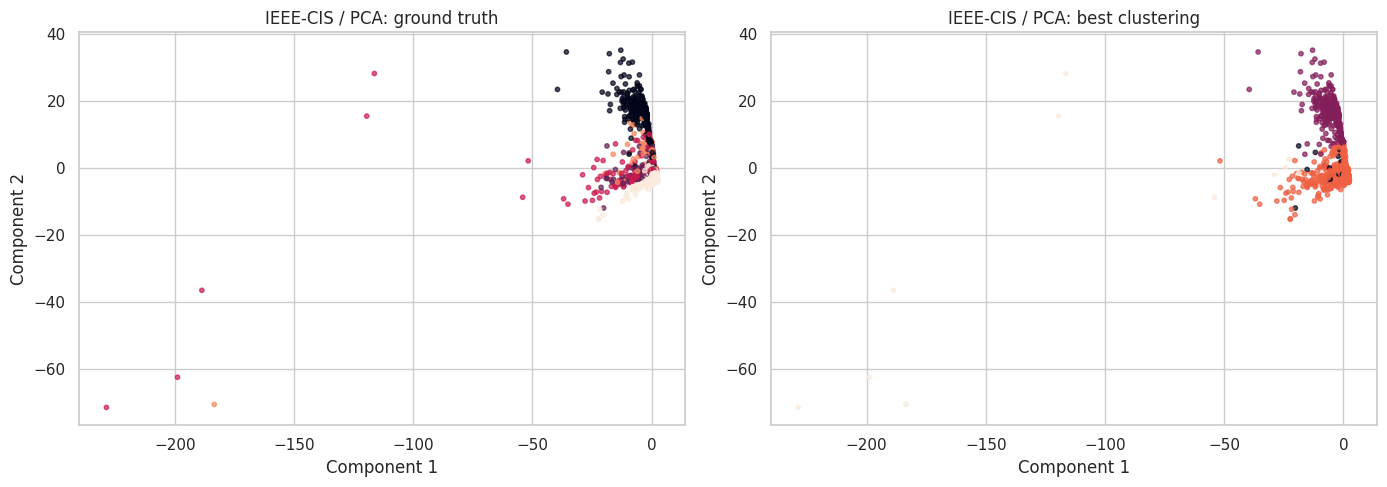

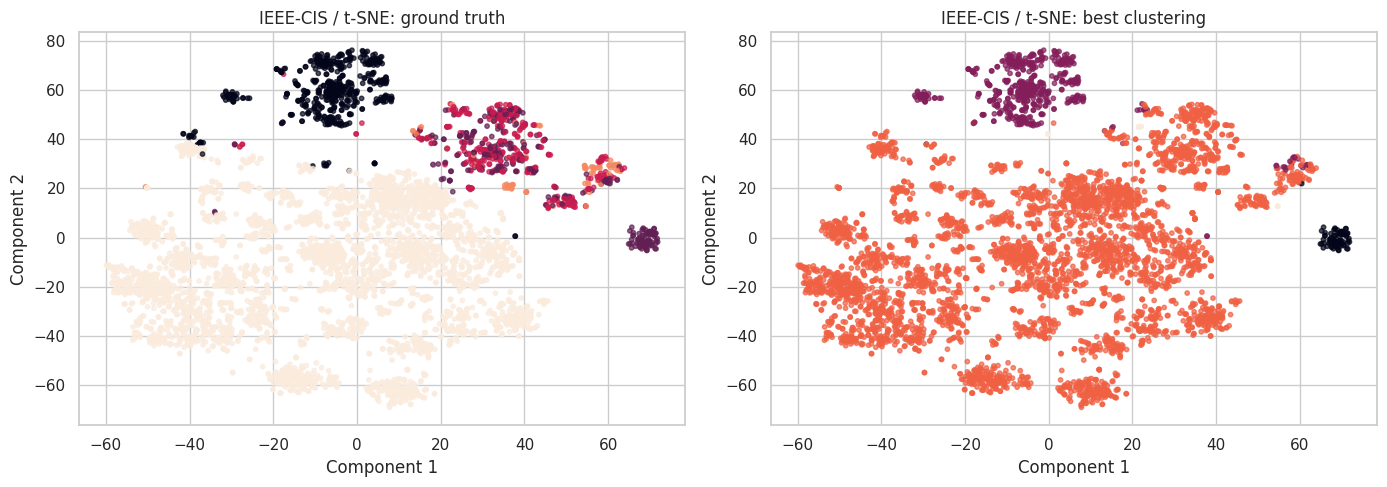

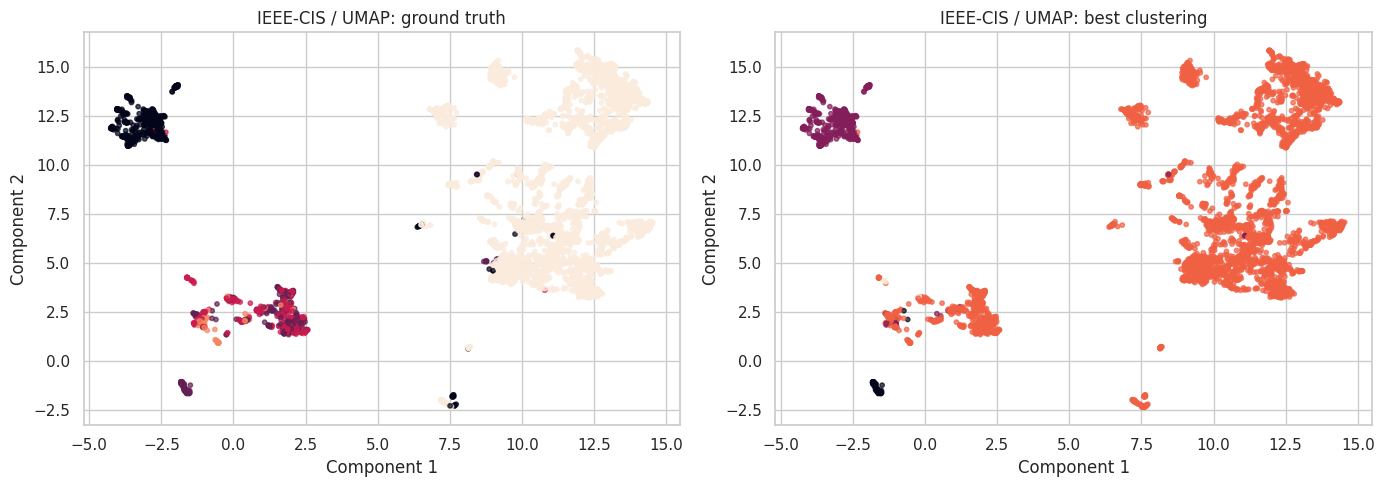

In [48]:
X_ieee_vis, y_ieee_vis, labels_ieee_vis = make_visual_sample(
    X_ieee, y_ieee, best_ieee_labels, sample_size=5000, random_state=42
)

ieee_embeddings = get_embeddings_2d(X_ieee_vis, random_state=42)

for method_name, emb in ieee_embeddings.items():
    plot_comparison(emb, y_ieee_vis, labels_ieee_vis, title_prefix=f"IEEE-CIS / {method_name}")

Аналогично построим визуализации для датасета NYC Taxi.

Сравним распределение объектов по псевдо-таргету и по результатам кластеризации в двумерном пространстве для разных методов понижения размерности.

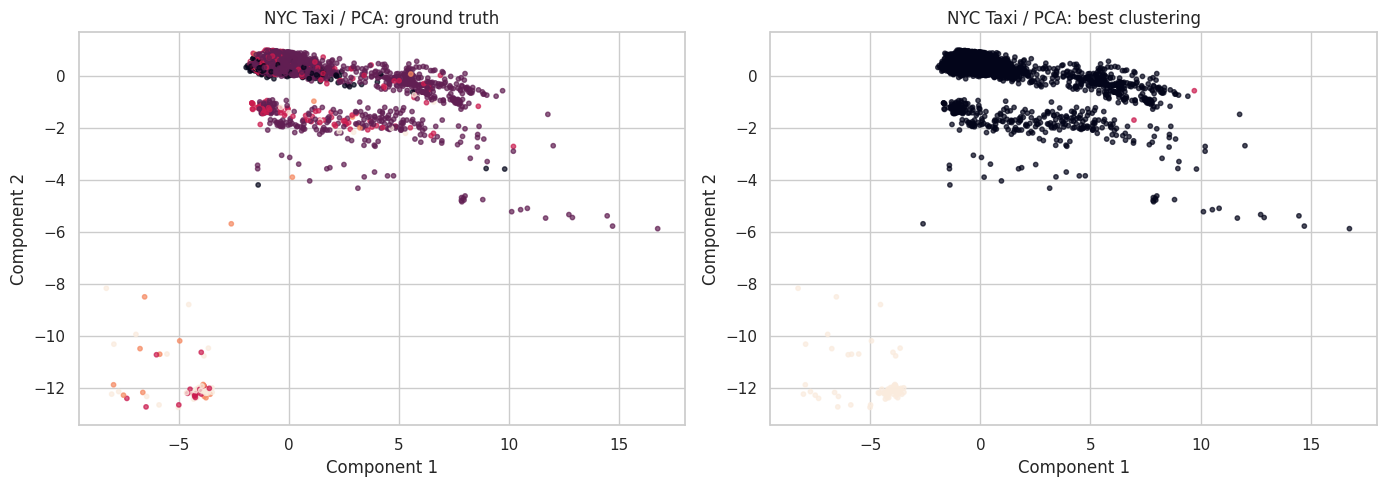

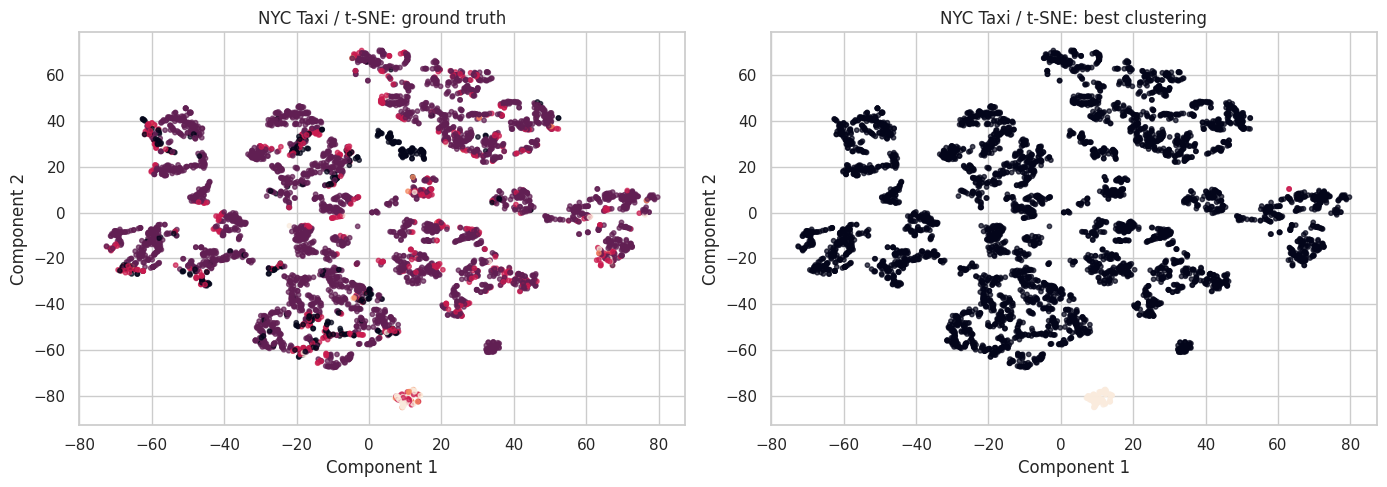

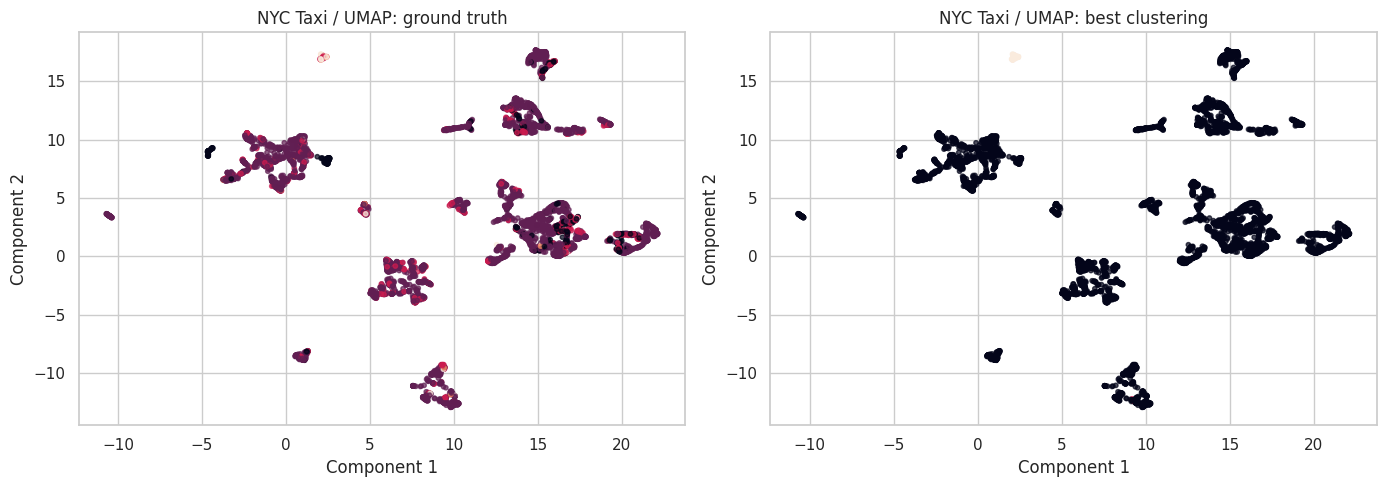

In [49]:
X_nyc_vis, y_nyc_vis, labels_nyc_vis = make_visual_sample(
    X_nyc, y_nyc, best_nyc_labels, sample_size=5000, random_state=42
)

nyc_embeddings = get_embeddings_2d(X_nyc_vis, random_state=42)

for method_name, emb in nyc_embeddings.items():
    plot_comparison(emb, y_nyc_vis, labels_nyc_vis, title_prefix=f"NYC Taxi / {method_name}")

По визуализациям для IEEE-CIS можно заметить, что кластеры частично совпадают с псевдо-таргетом. Это особенно видно на проекциях t-SNE и UMAP, где наблюдается некоторое разделение групп.

Тем не менее, полного совпадения нет, что согласуется с полученными значениями метрик.

Для NYC Taxi визуализации показывают, что кластеры практически не совпадают с псевдо-таргетом payment_type.

Точки разных классов сильно перемешаны, что подтверждает низкие значения V-measure и слабую связь между признаками и псевдо-таргетом.

### Вывод

В ходе работы были исследованы методы кластеризации и понижения размерности на датасетах NYC Taxi и IEEE-CIS Fraud Detection.

1. Сравнение алгоритмов кластеризации

    Проведённые эксперименты показали, что качество кластеризации существенно зависит как от выбранного алгоритма, так и от структуры данных:

    k-means продемонстрировал стабильные результаты при правильном выборе числа кластеров k. Алгоритм хорошо работает на данных с относительно компактными и сферическими кластерами, однако чувствителен к инициализации и масштабу признаков.
    Агломеративная кластеризация показала большую гибкость за счёт выбора стратегии объединения (linkage), что позволило лучше адаптироваться к различным структурам данных.
    DBSCAN оказался эффективным для выявления плотных областей и выбросов, однако его качество сильно зависит от параметров eps и min_samples, а также снижается на данных с неоднородной плотностью.

    По совокупности внутренних и внешних метрик (в частности, V-measure и silhouette score) были выбраны оптимальные конфигурации, обеспечивающие наилучший баланс между компактностью кластеров и их соответствием псевдо-таргету.

2. Сравнение результатов на разных датасетах

    Для NYC Taxi кластеры оказались менее чётко разделимыми, что может быть связано с высокой шумностью и сложной природой данных.
    Для IEEE-CIS Fraud Detection наблюдалась более выраженная структура, благодаря чему некоторые алгоритмы (особенно иерархическая кластеризация) показали более высокие значения внешних метрик.

3. Сравнение методов понижения размерности

    Для визуализации использовались три метода:

    PCA (линейный метод) показал ограниченную способность к разделению кластеров, так как не учитывает нелинейную структуру данных.
    t-SNE обеспечил хорошее сохранение локальной структуры и позволил выявить компактные группы объектов, однако в ряде случаев искажал глобальные расстояния между кластерами.
    UMAP продемонстрировал наиболее сбалансированные результаты, сохраняя как локальную, так и глобальную структуру данных, что сделало визуализации наиболее интерпретируемыми.

4. Сравнение кластеризации и псевдо-таргета

    Визуальное сравнение раскрасок показало, что:

    в ряде случаев кластеры хорошо согласуются с псевдо-таргетом, что подтверждается высокими значениями homogeneity и completeness;
    однако полного совпадения не наблюдается, что ожидаемо, так как кластеризация выполняется без учителя и может выявлять альтернативные структуры в данных.

5. Основные выводы

    Кластеризация чувствительна к выбору гиперпараметров и требует тщательного подбора.
    Универсального алгоритма не существует — выбор зависит от структуры данных.
    Методы понижения размерности существенно влияют на интерпретацию результатов:
    PCA — для базового анализа,
    t-SNE — для выявления локальных структур,
    UMAP — для наиболее информативной визуализации.
    Псевдо-таргет является полезным инструментом для внешней оценки, но не полностью отражает внутреннюю структуру данных.

Таблица с экспериментами Google Sheets: https://docs.google.com/spreadsheets/d/1aUFoMMZO7wkHZNWC7LIulkFco3467nP9UDVT1i2jo2s/edit?gid=842013877#gid=842013877